# Part C — Random Forest & Model Comparison
**C 담당**: Part C | **가설 H5**: RF가 LR보다 예측 성능이 높을 것이다

**파이프라인**: 데이터 병합 → RF 모델링 → Leakage 탐지/제거 → Feature Importance → LR 비교

**입력 파일**: `cleaned_USvideos.csv` (from Part A), `features_partB.csv` (from Part B)

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 150

---
### 1. 데이터 로드 및 병합
- Part A `cleaned_USvideos.csv`와 Part B `features_partB.csv`를 `video_id` 기준으로 병합
- 두 파일에 중복된 컬럼 정리


In [2]:
# 데이터 로드
df_clean = pd.read_csv('cleaned_USvideos.csv')
df_features = pd.read_csv('features_partB.csv')

# video_id 기준으로 병합
df = pd.merge(df_clean, df_features, on='video_id', how='inner')

print('shape:', df.shape)
print(df.columns.tolist())

shape: (6249, 30)
['video_id', 'title', 'category_x', 'views', 'log_views_x', 'likes', 'log_likes', 'dislikes', 'comment_count', 'log_comment_count', 'publish_hour', 'publish_weekday_x', 'trending_lag', 'days_on_trending', 'tags', 'comments_disabled', 'ratings_disabled', 'category_y', 'log_views_y', 'title_len', 'word_count', 'caps_ratio', 'exclaim_cnt', 'question_cnt', 'has_number', 'has_bracket', 'tag_cnt', 'hour_bin', 'publish_weekday_y', 'publish_time']


In [3]:
# 중복 컬럼 정리
df = df.drop(columns=['category_y', 'publish_weekday_y', 'log_views_y', 'tags', 'publish_time', 'title'])
df = df.rename(columns={'category_x': 'category', 'publish_weekday_x': 'publish_weekday', 'log_views_x': 'log_views'})

print('정리 후 shape:', df.shape)
print(df.columns.tolist())

정리 후 shape: (6249, 24)
['video_id', 'category', 'views', 'log_views', 'likes', 'log_likes', 'dislikes', 'comment_count', 'log_comment_count', 'publish_hour', 'publish_weekday', 'trending_lag', 'days_on_trending', 'comments_disabled', 'ratings_disabled', 'title_len', 'word_count', 'caps_ratio', 'exclaim_cnt', 'question_cnt', 'has_number', 'has_bracket', 'tag_cnt', 'hour_bin']


- Part A 16개 컬럼 + Part B 14개 컬럼 병합 → 30개 컬럼
- 중복 컬럼 (`category`, `publish_weekday`, `log_views`) 정리 후 최종 **24개 컬럼, 6,249행**

---
### 2. 전처리
- 범주형 변수 (`category`, `hour_bin`) one-hot 인코딩
- target: `log_views` (로그 변환된 조회수)
- 학습/테스트 랜덤 split (8:2, random_state=42)


In [4]:
# 범주형 변수 인코딩
df = pd.get_dummies(df, columns=['category', 'hour_bin'])

# feature, target 분리
X = df.drop(columns=['video_id', 'views', 'log_views'])
y = df['log_views']

# 학습/테스트 분리 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set:', X_train.shape)
print('Test set:', X_test.shape)

Training set: (4999, 39)
Test set: (1250, 39)


- `category` 16개, `hour_bin` 4개 → one-hot 인코딩 후 총 39개 feature
- 학습 데이터 4,999행 / 테스트 데이터 1,250행 (8:2 split)

---
### 3. RF1 — 기본 모델 (Leakage 포함)
- 모든 변수 포함하여 학습
- `likes`, `dislikes` 등 data leakage 변수 포함된 상태


In [5]:
# Random Forest 학습 (RF1)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# 예측 및 평가
y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.4f}')
print(f'R²: {r2:.4f}')

RMSE: 0.6473
R²: 0.8760


R²가 0.876으로 매우 높게 나왔으나, `likes`/`dislikes`/`comment_count`는 조회수가 높아야 많이 달리는 변수 → data leakage 문제

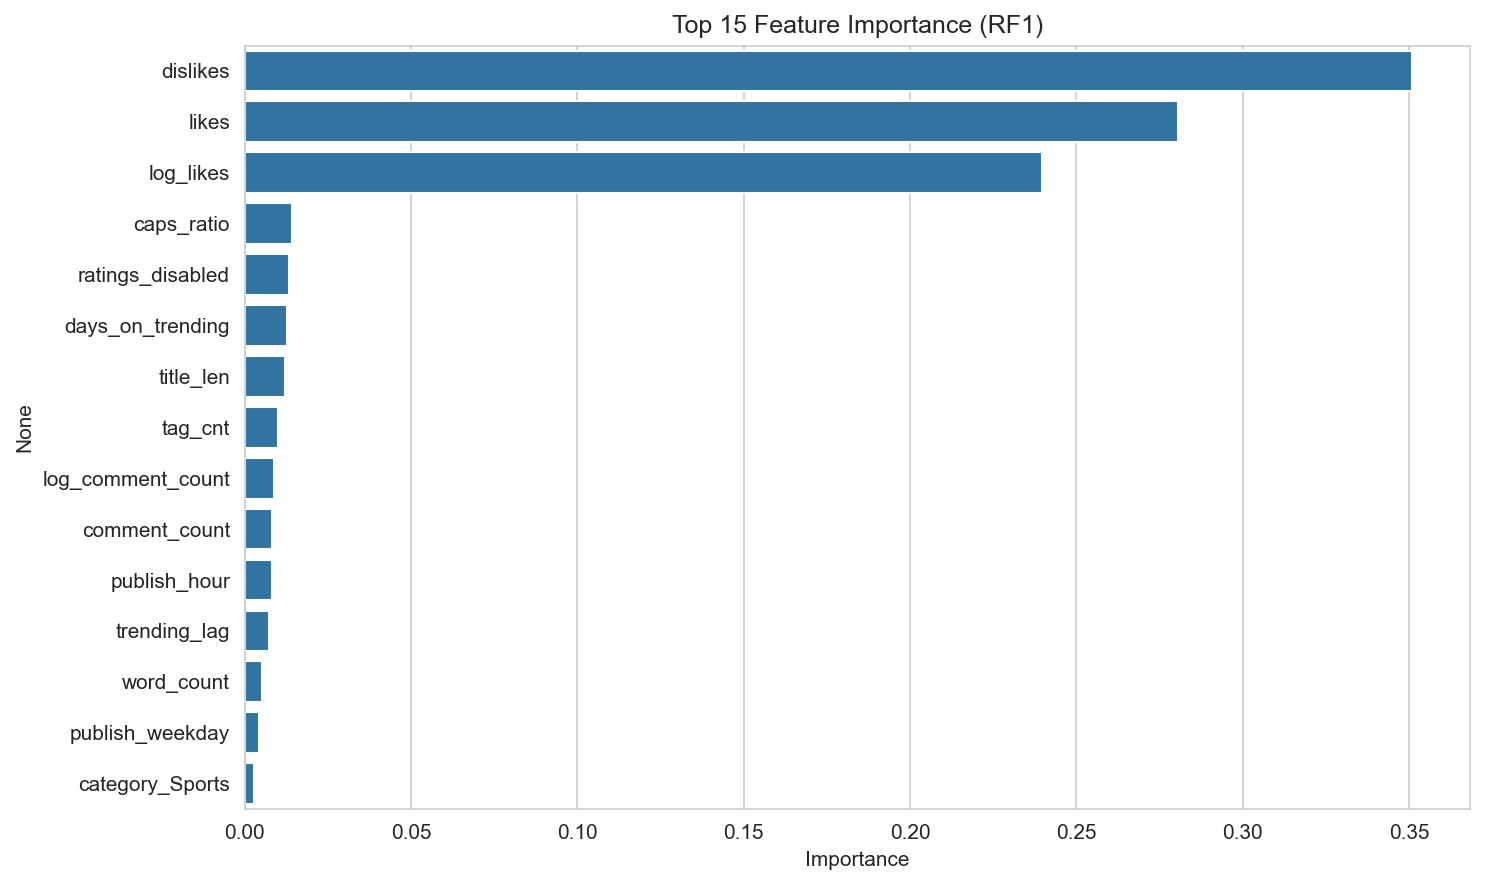

In [6]:
# Feature Importance 시각화 (RF1)
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Top 15 Feature Importance (RF1)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance.png', dpi=150)
plt.show()

- `dislikes`, `likes`, `log_likes`가 압도적 1~3위 → leakage 변수들이 모델을 지배하고 있음
- 실제 업로드 전 알 수 있는 변수들(`caps_ratio`, `title_len` 등)의 중요도는 매우 낮게 나타남

---
### 4. RF2 — 1차 Leakage 제거
- `likes`, `dislikes`, `comment_count`, `log_likes`, `log_comment_count` 제거
- 이유: 조회수가 높아야 좋아요/댓글도 많아지므로 인과관계 역전


In [7]:
# likes 관련 변수 제거 후 재학습 (RF2)
X2 = df.drop(columns=['video_id', 'views', 'log_views', 'likes', 'log_likes', 'dislikes', 'comment_count', 'log_comment_count'])
y = df['log_views']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y, test_size=0.2, random_state=42)

rf2 = RandomForestRegressor(n_estimators=100, random_state=42)
rf2.fit(X_train2, y_train2)
y_pred2 = rf2.predict(X_test2)

rmse2 = np.sqrt(mean_squared_error(y_test2, y_pred2))
r2_2 = r2_score(y_test2, y_pred2)

print(f'RMSE: {rmse2:.4f}')
print(f'R²: {r2_2:.4f}')

RMSE: 1.4245
R²: 0.3993


- R²가 0.876 → 0.399로 크게 하락 → leakage 변수 제거 효과 확인
- Feature Importance 확인 필요 → 추가 leakage 존재 가능성

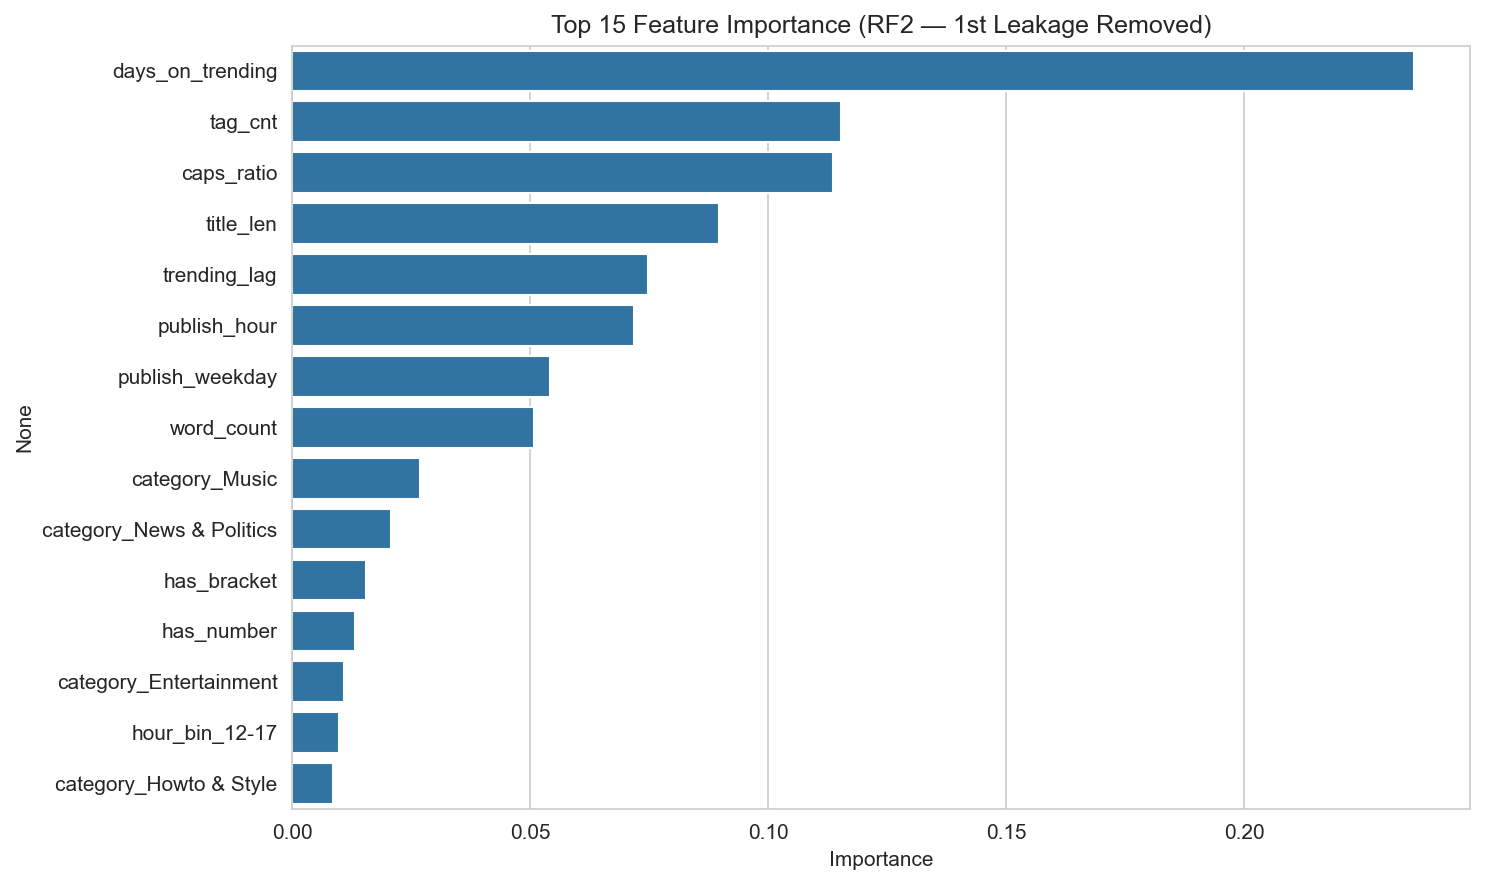

In [10]:
# Feature Importance 시각화 (RF2)
importances2 = pd.Series(rf2.feature_importances_, index=X2.columns)
importances2 = importances2.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances2.values, y=importances2.index)
plt.title('Top 15 Feature Importance (RF2 — 1st Leakage Removed)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance_v2.png', dpi=150)
plt.show()

- `days_on_trending`이 압도적 1위 → 추가 leakage 발견
- 트렌딩에 며칠 머물렀는지는 영상 업로드 후에야 알 수 있는 결과적 변수 → 인과관계 역전

---
### 5. RF3 — 최종 모델 (2차 Leakage 제거)
- `days_on_trending` 추가 제거
- 이유: 조회수가 높은 영상이 트렌딩에 오래 머무는 것 → 인과관계 역전
- 최종적으로 업로드 시점에 알 수 있는 변수만 사용

In [11]:
# days_on_trending도 제거 (RF3 최종 모델)
X3 = df.drop(columns=['video_id', 'views', 'log_views', 'likes', 'log_likes',
                       'dislikes', 'comment_count', 'log_comment_count', 'days_on_trending'])
y = df['log_views']

X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y, test_size=0.2, random_state=42)

rf3 = RandomForestRegressor(n_estimators=100, random_state=42)
rf3.fit(X_train3, y_train3)
y_pred3 = rf3.predict(X_test3)

rmse3 = np.sqrt(mean_squared_error(y_test3, y_pred3))
r2_3 = r2_score(y_test3, y_pred3)

print(f'RMSE: {rmse3:.4f}')
print(f'R²: {r2_3:.4f}')

RMSE: 1.5973
R²: 0.2448


- 업로드 전 알 수 있는 변수만으로 조회수의 약 24%를 설명
- 조회수는 콘텐츠 품질, 알고리즘 등 관측 불가능한 요인의 영향이 크므로 자연스러운 한계

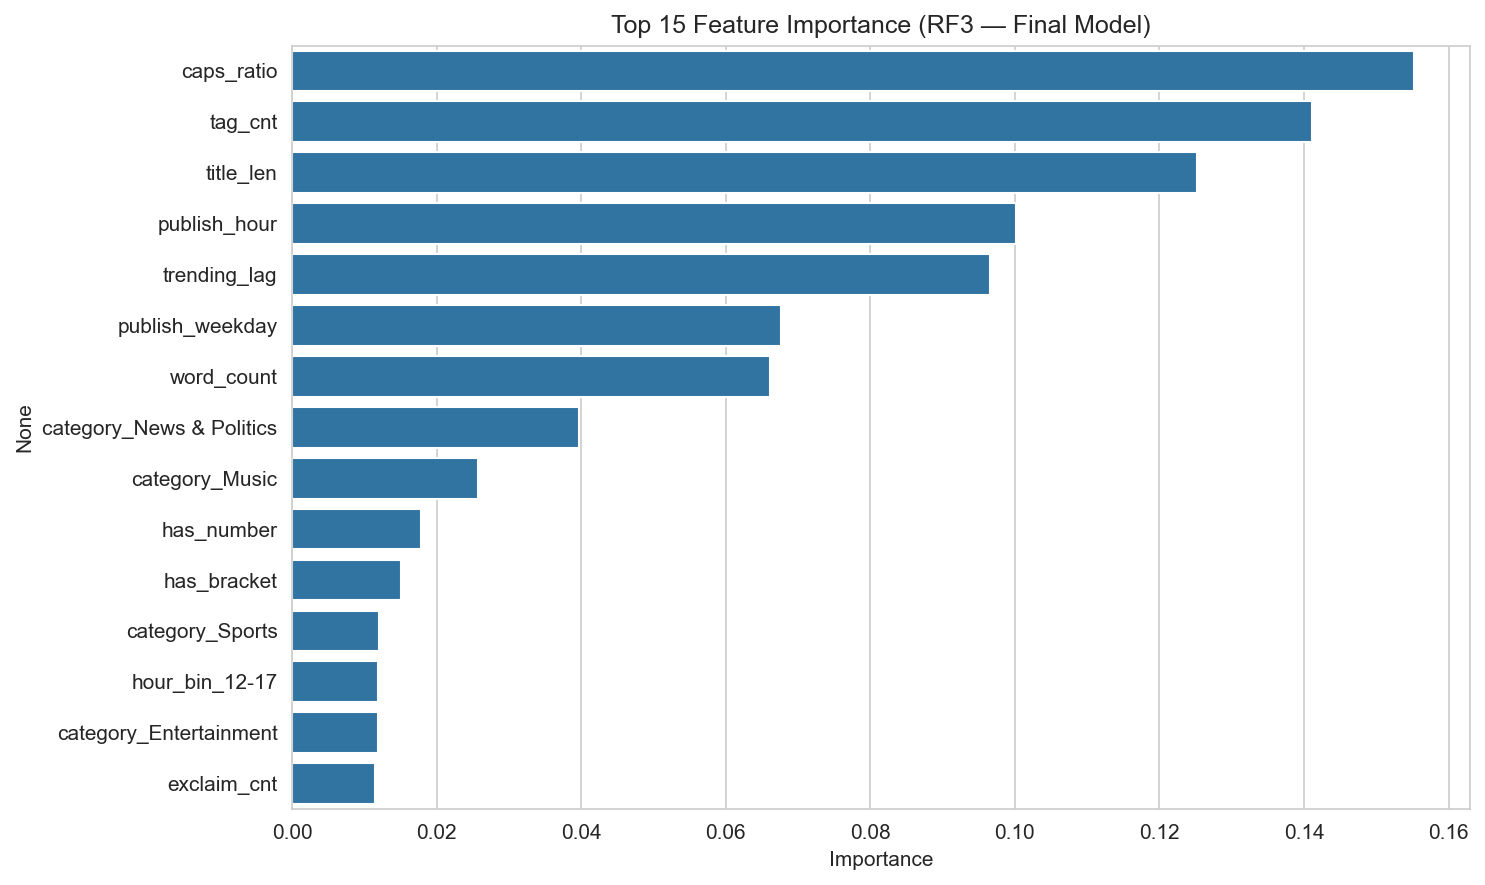

In [12]:
# Feature Importance 시각화 (RF3 최종 모델)
importances3 = pd.Series(rf3.feature_importances_, index=X3.columns)
importances3 = importances3.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances3.values, y=importances3.index)
plt.title('Top 15 Feature Importance (RF3 — Final Model)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('fig_rf_feature_importance_final.png', dpi=150)
plt.show()

leakage 변수 모두 제거 후 진짜 예측 변수들의 중요도가 드러남
- `caps_ratio` 1위 — 제목 대문자 비율이 높을수록 조회수 높음 (클릭베이트 효과)
- `tag_cnt` 2위 — 태그 수가 많을수록 노출 잘 됨
- `title_len` 3위 — 제목 길이가 중요
- `publish_hour` 4위 — 업로드 시간대가 조회수에 영향
- `category_Music`, `category_News & Politics` — 카테고리도 유의미한 영향

---
### 6. 하이퍼파라미터 튜닝 (RF3 기준)
- GridSearchCV를 사용하여 최적 하이퍼파라미터 탐색
- 탐색 범위: `n_estimators`, `max_depth`, `min_samples_split`


In [13]:
from sklearn.model_selection import GridSearchCV

# 탐색할 하이퍼파라미터 범위
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train3, y_train3)

print('최적 파라미터:', grid_search.best_params_)
print(f'최적 R²: {grid_search.best_score_:.4f}')

최적 파라미터: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
최적 R²: 0.1539


In [14]:
# 최적 파라미터로 재학습
rf3_tuned = RandomForestRegressor(
    max_depth=10,
    min_samples_split=5,
    n_estimators=200,
    random_state=42
)
rf3_tuned.fit(X_train3, y_train3)
y_pred_tuned = rf3_tuned.predict(X_test3)

rmse_tuned = np.sqrt(mean_squared_error(y_test3, y_pred_tuned))
r2_tuned = r2_score(y_test3, y_pred_tuned)

print(f'RMSE: {rmse_tuned:.4f}')
print(f'R²: {r2_tuned:.4f}')

RMSE: 1.5960
R²: 0.2460


최적 파라미터: max_depth=10, min_samples_split=5, n_estimators=200
- 기본 RF3 R²=0.2448 → 튜닝 후 R²=0.2460으로 소폭 개선
- 튜닝 효과가 크지 않은 이유: 데이터 자체의 설명력 한계 (관측 불가능한 요인이 많음)

---
### 7. 모델 비교 (LR vs RF)
- LR 결과: Part B `diag_test_r2.ipynb` 랜덤 split 기준 (R²=0.1155, RMSE=1.7553)
- 동일한 랜덤 split 조건으로 비교


In [15]:
# 모델 비교표
comparison = pd.DataFrame({
    '모델': ['LR (Baseline)', 'RF1 (Leakage 포함)', 'RF2 (1차 제거)', 'RF3 (최종)', 'RF3 (튜닝)'],
    'RMSE': [1.7553, 0.6473, 1.4245, 1.5973, 1.5960],
    'R²': [0.1155, 0.8760, 0.3993, 0.2448, 0.2460],
})

print(comparison.to_string(index=False))
comparison.to_csv('model_comparison.csv', index=False)

              모델   RMSE     R²
   LR (Baseline) 1.7553 0.1155
RF1 (Leakage 포함) 0.6473 0.8760
     RF2 (1차 제거) 1.4245 0.3993
        RF3 (최종) 1.5973 0.2448
        RF3 (튜닝) 1.5960 0.2460


RF3 (튜닝) 기준 LR 대비 성능 비교
- RMSE: 1.7553 → 1.5960 (개선)
- R²: 0.1155 → 0.2460 (개선)
- RF가 LR보다 높은 예측 성능 → **H5 가설 채택**
- RF1은 leakage로 인해 비정상적으로 높은 성능이었음

---
### 8. 잔차 분석 (RF3 튜닝 기준)


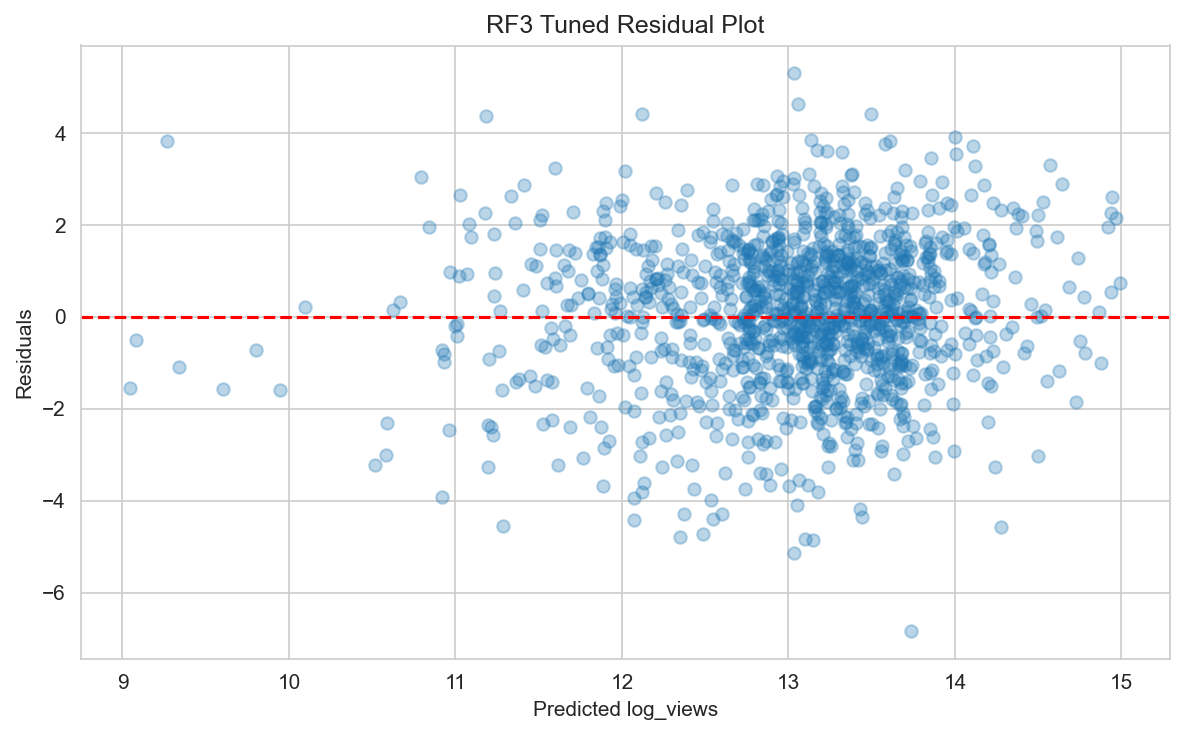

In [16]:
# 잔차 그래프 (RF3 튜닝 모델)
residuals = y_test3 - y_pred_tuned

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_tuned, residuals, alpha=0.3)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted log_views')
plt.ylabel('Residuals')
plt.title('RF3 Tuned Residual Plot')
plt.tight_layout()
plt.savefig('fig_rf_residuals.png', dpi=150)
plt.show()

- 전체적으로 잔차가 0 근처에 고르게 분포 → 모델이 크게 편향되지 않음
- 다만 예측값이 낮은 구간(x=9~11)에서 잔차 분산이 큼 → 저조회수 영상 예측이 불안정한 편

---
### 9. Feature Importance 저장


In [18]:
# Feature Importance CSV 저장 (RF3 튜닝 기준)
importance_df = pd.DataFrame({
    'feature': X3.columns,
    'importance': rf3_tuned.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.to_csv('feature_importance_final.csv', index=False)
print(importance_df.head(10).to_string(index=False))

                 feature  importance
            trending_lag    0.148973
                 tag_cnt    0.140958
              caps_ratio    0.135339
               title_len    0.098643
            publish_hour    0.085950
category_News & Politics    0.081882
         publish_weekday    0.054574
          category_Music    0.050334
              word_count    0.048865
             has_bracket    0.016166


---
### 10. 최종 인사이트


#### H5 가설 검증
LR(R²=0.116)보다 RF3 튜닝(R²=0.246)이 더 높은 성능 → H5 가설 채택

#### Feature Importance 해석
- `trending_lag`가 1위 — 빨리 트렌딩에 오른 영상일수록 조회수가 높은 경향
- `tag_cnt`, `caps_ratio`, `title_len` 순으로 중요 — 제목 스타일과 태그 수가 생각보다 중요한 변수
- `publish_hour`도 상위권 — 언제 올리느냐가 조회수에 영향을 줌
- 카테고리 중에선 Music, News & Politics가 유의미하게 나타남

#### 한계
- 업로드 전 알 수 있는 변수만 써서 R²가 0.246에 그침
- 구독자 수, 콘텐츠 품질 같은 변수는 데이터에 없어서 반영 못 함